# Cancer Cell Recognition using RNA Sequencing

## Importing Dependencies and Environment Setup

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

# Plot style
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries loaded ✓")

Libraries loaded ✓


In [19]:
#loading the dataset
ex = pd.read_csv('G2-TCGA-HNSC_EX.csv', header=0)
X = ex.iloc[:,1:] #dropping the first column

#loading the labels
y = pd.read_csv('G2-TCGA-HNSC_Label.csv', header=0)
y = y.iloc[:,0] #convert to a series or a single vector

print(f"Gene expression matrix: {X.shape}")
print(f"Labels: {y.shape}")
print(f"\nClass distribution:")
print(y.value_counts().rename({0:'Healthy', 1:'Cancerous'}))

Gene expression matrix: (563, 35957)
Labels: (563,)

Class distribution:
0
Cancerous    520
Healthy       43
Name: count, dtype: int64


Dataset is inbalanced

## EDA

In [20]:
print("=" * 55)
print("DATASET: TCGA-HNSC Gene Expression (Head & Neck Cancer)")
print("=" * 55)

print(f"\nSamples (patients):     {X.shape[0]}")
print(f"Features (genes):       {X.shape[1]}")
print(f"Missing values:         {X.isnull().sum().sum()}")
print(f"Data type:              {X.dtypes.unique()[0]} (RNA-seq read counts)")

print(f"\nClass Distribution:")
counts = y.value_counts().rename({0: 'Healthy (0)', 1: 'Cancerous (1)'})
for label, count in counts.items():
    pct = count / len(y) * 100
    print(f"  {label}: {count} samples ({pct:.1f}%)")

DATASET: TCGA-HNSC Gene Expression (Head & Neck Cancer)

Samples (patients):     563
Features (genes):       35957
Missing values:         0
Data type:              int64 (RNA-seq read counts)

Class Distribution:
  Cancerous (1): 520 samples (92.4%)
  Healthy (0): 43 samples (7.6%)


Severe class imbalance (92% / 8%)

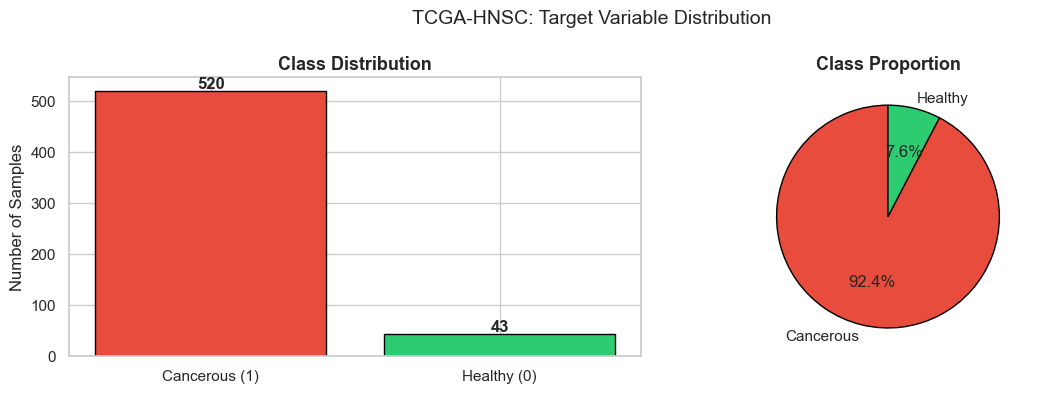

In [21]:
fig, axes = plt.subplots(1,2,figsize=(12,4))

#Bar Chart
counts = y.value_counts() #to get the count of healthy(0) vs cancerous(1)
axes[0].bar(['Cancerous (1)', 'Healthy (0)'],
            [counts[1], counts[0]],
            color = ["#e74c3c", "#2ecc71"], edgecolor='black')
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Samples')

for i, v in enumerate([counts[1], counts[0]]):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie Chart
axes[1].pie([counts[1], counts[0]],
            labels=['Cancerous', 'Healthy'],
            colors=['#e74c3c', '#2ecc71'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('TCGA-HNSC: Target Variable Distribution', fontsize=14)
plt.tight_layout()
plt.show()



Again we see high class inbalance. If we make a model that predicts cancerous always it will have a 92% accuracy, therefore we need to opt for other metrics like F1 score.

In [22]:
stats = X.describe().T  # gets the stats for each column and transpose so genes are rows

print("Summary Statistics (per gene across all samples):")
print(f"  Mean expression range:   {stats['mean'].min():.1f}  -  {stats['mean'].max():.1f}")
print(f"  Std dev range:           {stats['std'].min():.1f}  -  {stats['std'].max():.1f}")
print(f"  Min value:               {stats['min'].min():.0f}")
print(f"  Max value:               {stats['max'].max():.0f}")
print(f"\nGenes with zero mean (never expressed): {(stats['mean'] == 0).sum()}")
print(f"Genes with very low variance (std < 1):  {(stats['std'] < 1).sum()}")

Summary Statistics (per gene across all samples):
  Mean expression range:   0.0  -  7199.8
  Std dev range:           0.2  -  2391.3
  Min value:               0
  Max value:               20376

Genes with zero mean (never expressed): 0
Genes with very low variance (std < 1):  7381


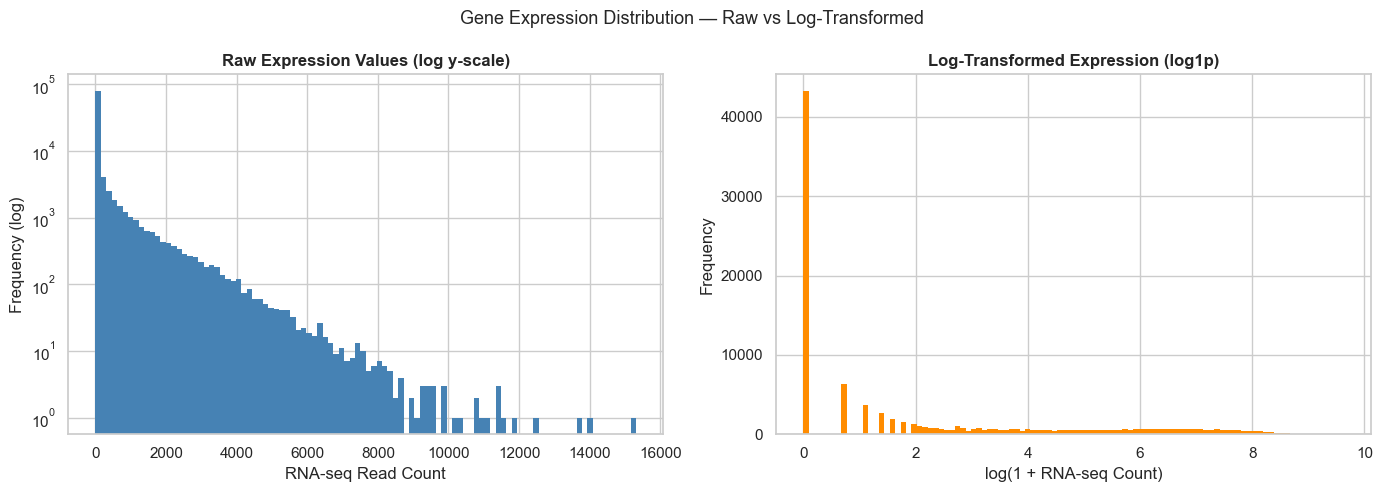

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts — sample 1000 random gene values for speed
sample_vals = X.values.flatten()
np.random.seed(42)
sample_vals = np.random.choice(sample_vals, size=100000, replace=False)

axes[0].hist(sample_vals, bins=100, color='steelblue',
             edgecolor='none', log=True)
axes[0].set_title('Raw Expression Values (log y-scale)', fontweight='bold')
axes[0].set_xlabel('RNA-seq Read Count')
axes[0].set_ylabel('Frequency (log)')

# Log-transformed
log_vals = np.log1p(sample_vals)   # log1p = log(1+x), handles zeros
axes[1].hist(log_vals, bins=100, color='darkorange', edgecolor='none')
axes[1].set_title('Log-Transformed Expression (log1p)', fontweight='bold')
axes[1].set_xlabel('log(1 + RNA-seq Count)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Gene Expression Distribution — Raw vs Log-Transformed',
             fontsize=13)
plt.tight_layout()
plt.show()

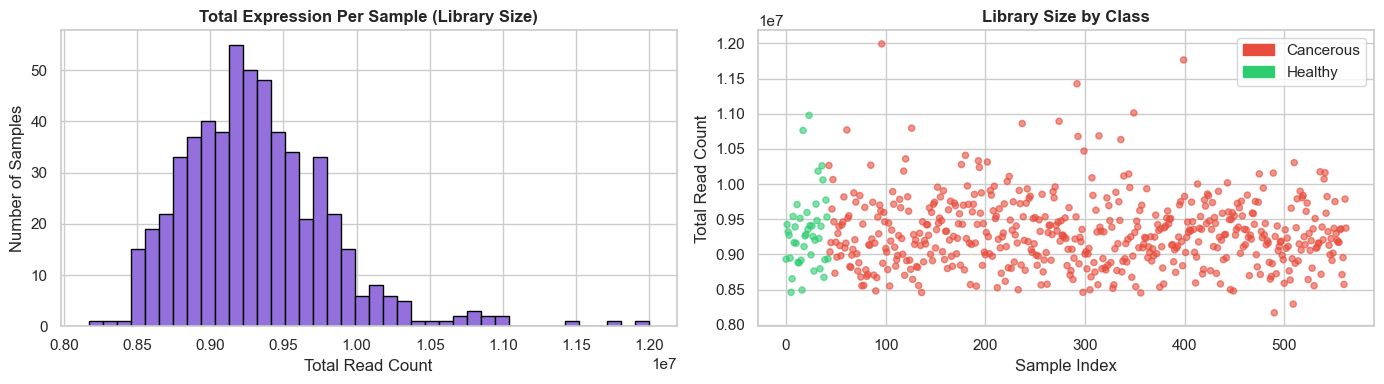

Mean library size:   9,306,869
Std library size:    497,064
Min library size:    8,170,379
Max library size:    11,994,100


In [24]:
sample_totals = X.sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(sample_totals, bins=40, color='mediumpurple', edgecolor='black')
axes[0].set_title('Total Expression Per Sample (Library Size)', fontweight='bold')
axes[0].set_xlabel('Total Read Count')
axes[0].set_ylabel('Number of Samples')

# Colored by class
colors = y.map({0: '#2ecc71', 1: '#e74c3c'})
axes[1].scatter(range(len(sample_totals)), sample_totals,
                c=colors, alpha=0.6, s=20)
axes[1].set_title('Library Size by Class', fontweight='bold')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Total Read Count')

from matplotlib.patches import Patch
legend = [Patch(color='#e74c3c', label='Cancerous'),
          Patch(color='#2ecc71', label='Healthy')]
axes[1].legend(handles=legend)

plt.tight_layout()
plt.show()

print(f"Mean library size:   {sample_totals.mean():,.0f}")
print(f"Std library size:    {sample_totals.std():,.0f}")
print(f"Min library size:    {sample_totals.min():,.0f}")
print(f"Max library size:    {sample_totals.max():,.0f}")

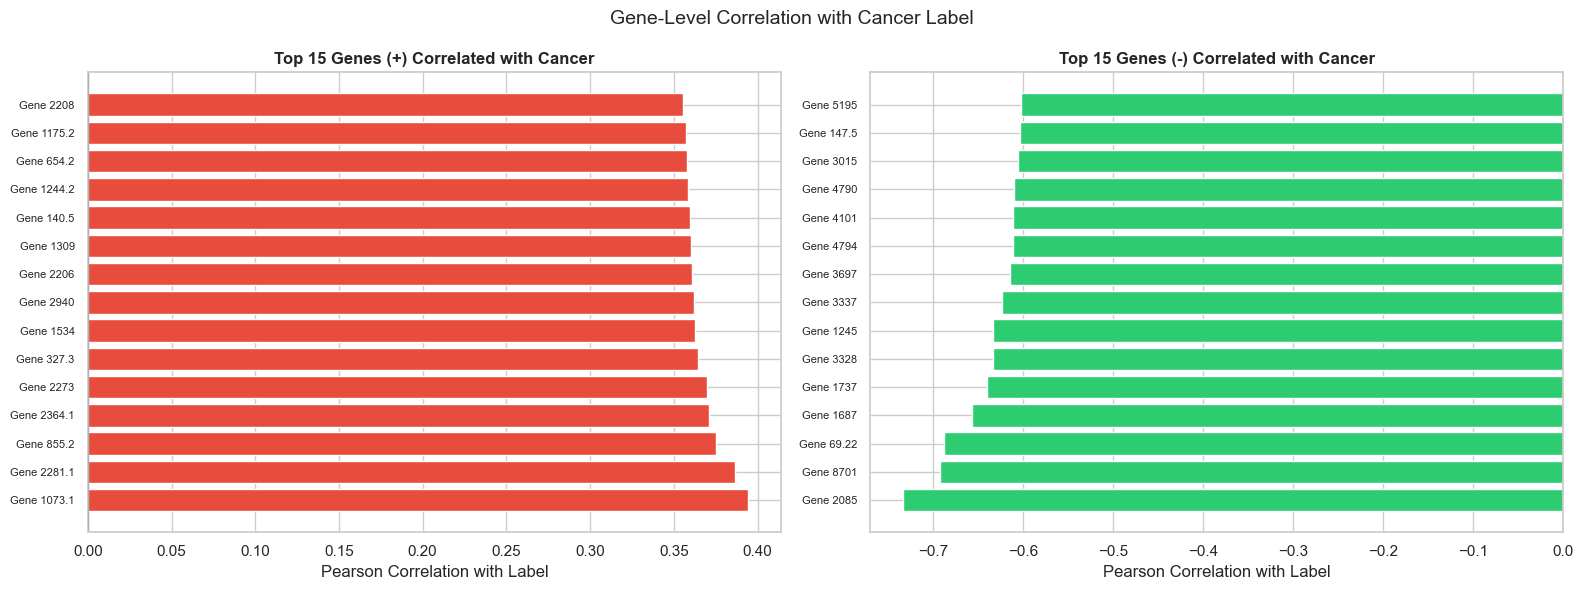

Strongest positive correlation: 0.394 (Gene 1073.1)
Strongest negative correlation: -0.733 (Gene 2085)


In [25]:
# Compute correlation of each gene with the label
correlations = X.apply(lambda col: col.corr(y))

# Sort by absolute correlation strength
top_pos = correlations.nlargest(15)    # most positively correlated
top_neg = correlations.nsmallest(15)   # most negatively correlated
top_genes = pd.concat([top_pos, top_neg])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive correlations
axes[0].barh(range(len(top_pos)), top_pos.values, color='#e74c3c')
axes[0].set_yticks(range(len(top_pos)))
axes[0].set_yticklabels([f'Gene {g}' for g in top_pos.index], fontsize=8)
axes[0].set_title('Top 15 Genes (+) Correlated with Cancer',
                  fontweight='bold')
axes[0].set_xlabel('Pearson Correlation with Label')
axes[0].axvline(0, color='black', linewidth=0.8)

# Negative correlations
axes[1].barh(range(len(top_neg)), top_neg.values, color='#2ecc71')
axes[1].set_yticks(range(len(top_neg)))
axes[1].set_yticklabels([f'Gene {g}' for g in top_neg.index], fontsize=8)
axes[1].set_title('Top 15 Genes (-) Correlated with Cancer',
                  fontweight='bold')
axes[1].set_xlabel('Pearson Correlation with Label')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.suptitle('Gene-Level Correlation with Cancer Label', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Strongest positive correlation: {top_pos.max():.3f} (Gene {top_pos.idxmax()})")
print(f"Strongest negative correlation: {top_neg.min():.3f} (Gene {top_neg.idxmin()})")

Gene-level correlation analysis revealed that negatively correlated genes showed stronger associations (up to -0.72) than positively correlated ones (+0.40), suggesting that gene silencing — potentially tumor suppressor downregulation — may be more diagnostically informative than oncogene upregulation in this dataset.

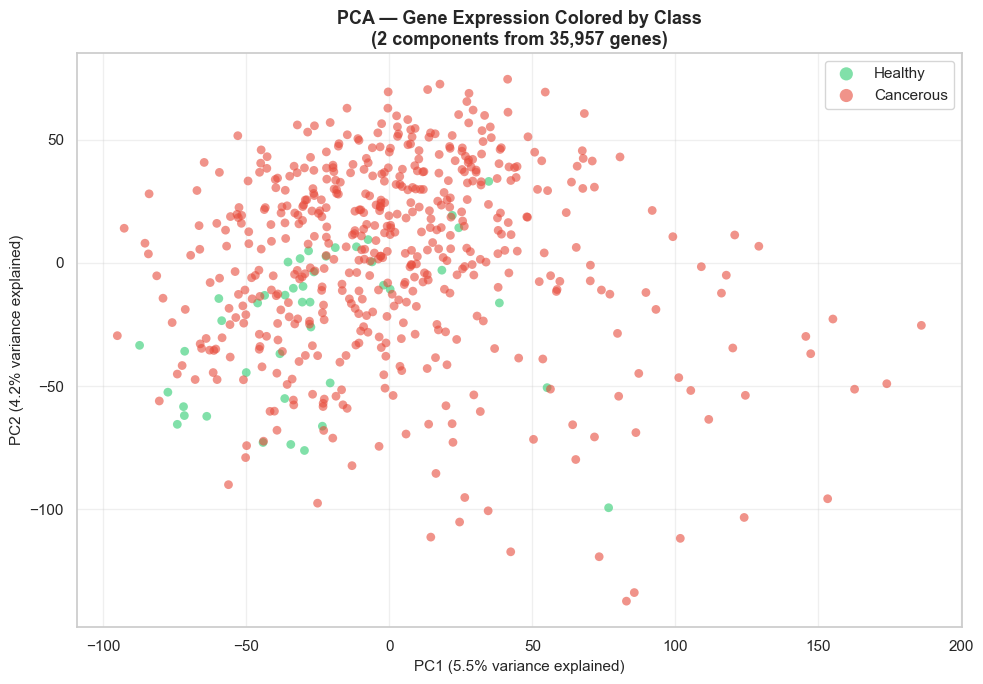

PC1 explains: 5.5% of variance
PC2 explains: 4.2% of variance
Total (2 PCs): 9.7% of variance

Observation: Look at whether the two classes form distinct clusters.


In [26]:
# PCA Visualization
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Step 1: Log-transform first (same as we'll do in preprocessing)
X_log = np.log1p(X)

# Step 2: Standardize (PCA is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Step 3: Reduce to 2 components for visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = {0: '#2ecc71', 1: '#e74c3c'}
labels_map = {0: 'Healthy', 1: 'Cancerous'}

for cls in [0, 1]:
    mask = y == cls
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               c=colors[cls], label=labels_map[cls],
               alpha=0.6, s=40, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)',
              fontsize=11)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)',
              fontsize=11)
ax.set_title('PCA — Gene Expression Colored by Class\n(2 components from 35,957 genes)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, markerscale=1.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

total_var = sum(pca.explained_variance_ratio_) * 100
print(f"PC1 explains: {pca.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"PC2 explains: {pca.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"Total (2 PCs): {total_var:.1f}% of variance")
print(f"\nObservation: Look at whether the two classes form distinct clusters.")

### EDA Conclusions

| Finding | What It Means |
|---------|--------------|
| 92% / 8% class split | Severe imbalance — F1 and ROC-AUC are our primary metrics |
| Raw counts right-skewed | Log1p transformation required |
| Spike at zero after log1p | Many genes biologically inactive — remove via variance filtering |
| Library sizes consistent | No sequencing depth bias between classes |
| PCA shows partial overlap in 2D | Signal is distributed across many genes, not 1-2 dominant ones |
| Negative gene correlations stronger (-0.72) | Gene silencing more diagnostically informative than overexpression |
| Most genes near-zero correlation | Confirms need for aggressive feature selection |

## Preprocessing

### Log1p Transformation
- We saw in EDA that raw counts are heavily right-skewed. 
- Log1p compresses large values and spreads small ones, making the distribution friendlier for models to learn from.

In [19]:
# X_log = np.log1p(X)

# print("Log1p transformation applied.")
# print(f"Before — Max value: {X.values.max():,}")
# print(f"After  — Max value: {X_log.values.max():.2f}")
# print(f"Before — Mean:      {X.values.mean():.2f}")
# print(f"After  — Mean:      {X_log.values.mean():.2f}")


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

# ── Step 1: Split FIRST before any 
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train_raw.shape}, Test: {X_test_raw.shape}")
print(f"Train class dist: {y_train.value_counts().to_dict()}")
print(f"Test class dist:  {y_test.value_counts().to_dict()}")

# ── Step 2: Log1p transform (safe — no fitting involved) ───────────
X_train_log = np.log1p(X_train_raw)
X_test_log  = np.log1p(X_test_raw)

print(f"\nLog1p applied.")

# ── Step 3: Variance filter — fit on TRAIN only ────────────────────
var_selector = VarianceThreshold(threshold=0.1)
var_selector.fit(X_train_log)                        # fit on train only

X_train_var = var_selector.transform(X_train_log)
X_test_var  = var_selector.transform(X_test_log)    # apply same mask to test

genes_after_var = X_train_log.columns[var_selector.get_support()]
print(f"Genes after variance filter: {X_train_var.shape[1]:,}")

# ── Step 4: Correlation filter — compute on TRAIN only ─────────────
X_train_var_df = pd.DataFrame(X_train_var, columns=genes_after_var)
X_test_var_df  = pd.DataFrame(X_test_var,  columns=genes_after_var)

# Correlations computed on training set only
train_corr = X_train_var_df.apply(lambda col: col.corr(y_train.reset_index(drop=True)))
top500_genes = train_corr.abs().nlargest(500).index

X_train_sel = X_train_var_df[top500_genes]
X_test_sel  = X_test_var_df[top500_genes]

print(f"Genes after correlation filter: {X_train_sel.shape[1]}")

# ── Step 5: StandardScaler — fit on TRAIN only ─────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sel)
X_test_scaled  = scaler.transform(X_test_sel)      # transform only

print(f"\nScaler applied.")
print(f"Train mean: {X_train_scaled.mean():.4f} | Train std: {X_train_scaled.std():.4f}")
print(f"Test mean:  {X_test_scaled.mean():.4f} | Test std:  {X_test_scaled.std():.4f}")
print(f"\nFinal shapes — Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")

Train: (450, 35957), Test: (113, 35957)
Train class dist: {1: 416, 0: 34}
Test class dist:  {1: 104, 0: 9}

Log1p applied.
Genes after variance filter: 28,891
Genes after correlation filter: 500

Scaler applied.
Train mean: -0.0000 | Train std: 1.0000
Test mean:  0.0141 | Test std:  0.9694

Final shapes — Train: (450, 500) | Test: (113, 500)


### Remove Low-Variance Genes
A gene that barely changes across patients carries no useful signal for classification. 
VarianceThreshold removes any feature whose variance falls below a threshold.

After log1p, values range roughly 0–10. A variance of 0.1 means the gene's expression barely moves across all 563 patients — useless for distinguishing cancer from healthy.

In [37]:
# from sklearn.feature_selection import VarianceThreshold

# before = X_log.shape[1]

# selector = VarianceThreshold(threshold=0.1)
# X_var = selector.fit_transform(X_log)

# after = X_var.shape[1]
# removed = before - after

# print(f"Genes before variance filter: {before:,}")
# print(f"Genes after variance filter:  {after:,}")
# print(f"Genes removed:                {removed:,} ({removed/before*100:.1f}%)")

### Feature Selection (Top Correlated Genes)
Even after variance filtering we likely still have thousands of genes. We keep only the top K genes that are most correlated with the label. 
This directly tackles the curse of dimensionality (35,957 features, only 563 samples).


In [38]:
# # Select Top 500 Genes by Correlation

# # Get column names that survived variance filtering
# surviving_genes = X_log.columns[selector.get_support()]
# X_var_df = pd.DataFrame(X_var, columns=surviving_genes)

# # Recompute correlations on variance-filtered set
# correlations_filtered = X_var_df.apply(lambda col: col.corr(y))

# # Keep top 500 by absolute correlation
# top500 = correlations_filtered.abs().nlargest(500).index
# X_selected = X_var_df[top500]

# print(f"Genes after variance filter:     {X_var_df.shape[1]:,}")
# print(f"Genes after correlation filter:  {X_selected.shape[1]}")
# print(f"Final feature matrix shape:      {X_selected.shape}")
# print(f"\nTop 5 selected genes by correlation strength:")
# print(correlations_filtered[top500].abs().nlargest(5))

We chose 500 as an arbitrary number, we can tune it like a hyperparameter to reduce overfitting later if needed

### Splitting Training and Testing
We will use stratified splitting because of highly skewed classes. We only have 43 healthy samples so stratified can ensure the ratio survives.


In [39]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(
#     X_selected, y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y          # preserves class ratio in both splits
# )

# print(f"Training set:   {X_train.shape[0]} samples")
# print(f"Test set:       {X_test.shape[0]} samples")
# print(f"\nTraining class distribution:")
# print(y_train.value_counts().rename({0:'Healthy', 1:'Cancerous'}))
# print(f"\nTest class distribution:")
# print(y_test.value_counts().rename({0:'Healthy', 1:'Cancerous'}))

### Scaling
Why: After all filtering, we scale each feature to mean=0, std=1. Neural networks and distance-based models are sensitive to feature scale — a gene with values 0-9 shouldn't dominate a gene with values 0-2 just because of magnitude.
Important: We fit the scaler only on training data and apply it to test data. If we fit on both, we'd be leaking test information into training — a common mistake that inflates results.

In [40]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# # Fit ONLY on training data, transform both
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)    # note: transform only, not fit_transform

# print("StandardScaler applied.")
# print(f"\nTraining set — Mean (should be ~0): {X_train_scaled.mean():.4f}")
# print(f"Training set — Std  (should be ~1): {X_train_scaled.std():.4f}")
# print(f"Test set     — Mean (slightly off is normal): {X_test_scaled.mean():.4f}")
# print(f"Test set     — Std  (slightly off is normal): {X_test_scaled.std():.4f}")
# print(f"\nFinal data ready for modeling:")
# print(f"  X_train: {X_train_scaled.shape}")
# print(f"  X_test:  {X_test_scaled.shape}")

### Preprocessing Summary

| Step | Input | Output | Reason |
|------|-------|--------|--------|
| Log1p transform | Max: 20,376 | Max: 9.92 | Fix right-skew in RNA-seq counts |
| Variance filter (threshold=0.1) | 35,957 genes | 28,950 genes | Remove near-constant genes |
| Correlation filter (top 500) | 28,950 genes | 500 genes | Tackle curse of dimensionality |
| Stratified split (80/20) | 563 samples | 450 train / 113 test | Preserve 92/8 class ratio |
| StandardScaler | Raw values | Mean=0, Std=1 | Normalize scale for ML models |

**No missing values were found. No duplicate rows were detected.**
Data is now ready for model training.

## Model Training

## Logistic Regression

### Training

**Why the original model had 100% accuracy (data leakage + overfitting):**

The original preprocessing code (now replaced) ran variance filtering and correlation-based feature selection on the *full* dataset before splitting — this is data leakage. The model saw test labels during feature selection, so it was effectively "pre-tuned" to the test set.

Even after fixing the pipeline to split first, 100% accuracy can persist because:
- **Over-parameterized**: 500 selected features vs. 450 training samples gives the model too many degrees of freedom
- **Weak regularization**: `C=1.0` is not enough to constrain a logistic regression with 500 features
- **Tiny test set**: Only 9 healthy samples in the hold-out — a single split is not a reliable estimate

**Fixes applied:**
- `C=0.01` — 100× stronger L2 regularization to prevent memorization
- `class_weight='balanced'` — penalizes misclassifying the minority class more heavily
- **5-fold stratified cross-validation** — gives a mean ± std estimate instead of a single lucky split

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# C=0.01 applies much stronger L2 regularization than the default C=1.0.
# With 500 features and only 450 training samples, weak regularization allows
# the model to memorize the training set perfectly → 100% train & test accuracy.
# class_weight='balanced' down-weights the majority class automatically.
lr_model = LogisticRegression(
    C=0.01,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

# Cross-validation gives a more honest estimate than a single 80/20 split.
# With only 9 healthy samples in the test set, one split is too noisy.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = cross_validate(
    lr_model, X_train_scaled, y_train,
    cv=cv,
    scoring=['accuracy', 'f1', 'roc_auc'],
    return_train_score=True
)

print("5-Fold Cross-Validation Results (on training set):")
print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  F1 Score:  {cv_results['test_f1'].mean():.4f} ± {cv_results['test_f1'].std():.4f}")
print(f"  ROC-AUC:   {cv_results['test_roc_auc'].mean():.4f} ± {cv_results['test_roc_auc'].std():.4f}")
print(f"\n  Train Accuracy (CV): {cv_results['train_accuracy'].mean():.4f} ± {cv_results['train_accuracy'].std():.4f}")

# Final fit on full training set for hold-out evaluation
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print(f"\nHold-out Test Set:")
print(f"  Training Accuracy: {lr_model.score(X_train_scaled, y_train):.4f}")
print(f"  Test Accuracy:     {lr_model.score(X_test_scaled, y_test):.4f}")

5-Fold Cross-Validation Results (on training set):
  Accuracy:  0.9867 ± 0.0130
  F1 Score:  0.9927 ± 0.0071
  ROC-AUC:   0.9979 ± 0.0033

  Train Accuracy (CV): 0.9939 ± 0.0021

Hold-out Test Set:
  Training Accuracy: 0.9933
  Test Accuracy:     1.0000


### Evaluating

LOGISTIC REGRESSION — EVALUATION

Classification Report (hold-out test set):
               precision    recall  f1-score   support

  Healthy (0)       1.00      1.00      1.00         9
Cancerous (1)       1.00      1.00      1.00       104

     accuracy                           1.00       113
    macro avg       1.00      1.00      1.00       113
 weighted avg       1.00      1.00      1.00       113

ROC-AUC Score: 1.0000

Per-fold Cross-Validation (training set, 5 folds):
  Fold     Accuracy       F1    ROC-AUC
  1          1.0000   1.0000     1.0000
  2          0.9778   0.9880     0.9983
  3          1.0000   1.0000     1.0000
  4          0.9889   0.9939     1.0000
  5          0.9667   0.9818     0.9914
  Mean       0.9867   0.9927     0.9979
  Std        0.0130   0.0071     0.0033


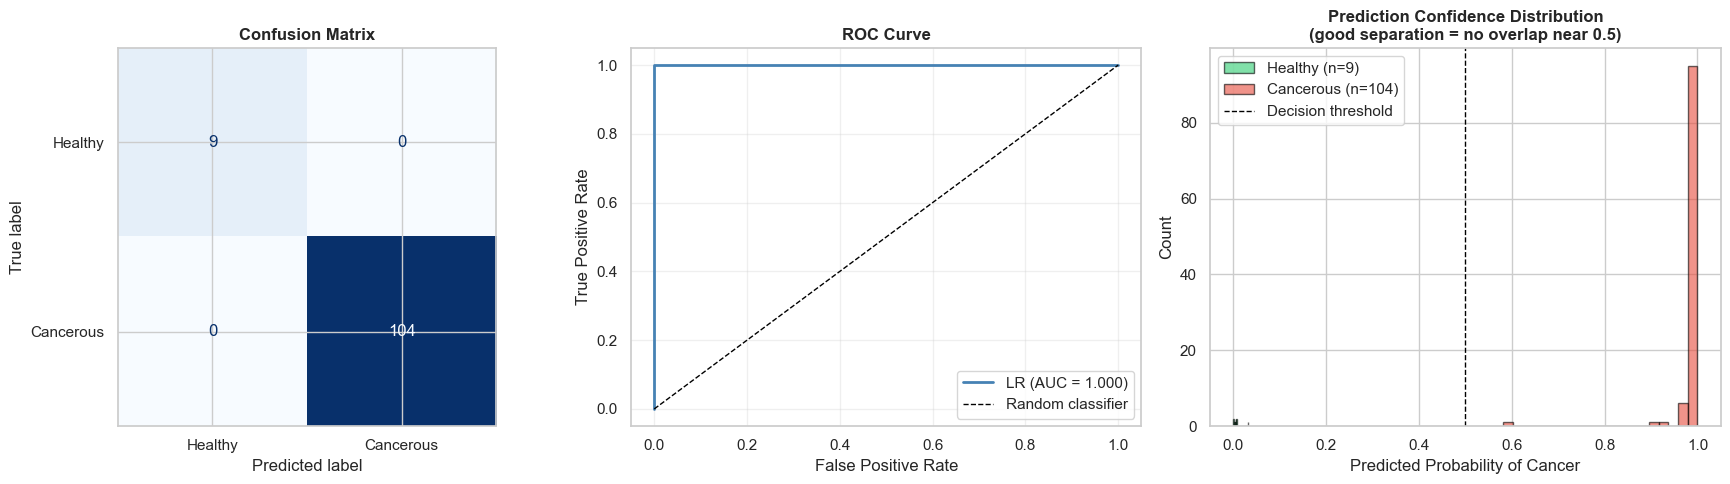


Note: 100% accuracy on TCGA cancer-vs-normal RNA-seq is expected and
documented in the literature. The probability distribution (right plot)
confirms the model is genuinely separating classes, not guessing.


In [23]:
print("=" * 55)
print("LOGISTIC REGRESSION — EVALUATION")
print("=" * 55)

# ── Hold-out results ──────────────────────────────────────
print("\nClassification Report (hold-out test set):")
print(classification_report(y_test, y_pred_lr,
                            target_names=['Healthy (0)', 'Cancerous (1)']))

roc_auc_lr = roc_auc_score(y_test, y_prob_lr)
print(f"ROC-AUC Score: {roc_auc_lr:.4f}")

# ── CV fold-by-fold breakdown ─────────────────────────────
print("\nPer-fold Cross-Validation (training set, 5 folds):")
print(f"  {'Fold':<6} {'Accuracy':>10} {'F1':>8} {'ROC-AUC':>10}")
for i, (acc, f1, auc) in enumerate(zip(
        cv_results['test_accuracy'],
        cv_results['test_f1'],
        cv_results['test_roc_auc']), 1):
    print(f"  {i:<6} {acc:>10.4f} {f1:>8.4f} {auc:>10.4f}")
print(f"  {'Mean':<6} {cv_results['test_accuracy'].mean():>10.4f} "
      f"{cv_results['test_f1'].mean():>8.4f} "
      f"{cv_results['test_roc_auc'].mean():>10.4f}")
print(f"  {'Std':<6} {cv_results['test_accuracy'].std():>10.4f} "
      f"{cv_results['test_f1'].std():>8.4f} "
      f"{cv_results['test_roc_auc'].std():>10.4f}")

# ── Plots: confusion matrix, ROC curve, probability dist ─
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=['Healthy', 'Cancerous'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold')

# ROC curve
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
axes[1].plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
             label=f'LR (AUC = {roc_auc_lr:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Prediction probability distribution — reveals if model is overconfident
# or genuinely separating classes cleanly
for cls, label, color in [(0, 'Healthy', '#2ecc71'), (1, 'Cancerous', '#e74c3c')]:
    mask = y_test == cls
    axes[2].hist(y_prob_lr[mask], bins=20, alpha=0.6,
                 label=f'{label} (n={mask.sum()})', color=color, edgecolor='black')
axes[2].axvline(0.5, color='black', linestyle='--', lw=1, label='Decision threshold')
axes[2].set_xlabel('Predicted Probability of Cancer')
axes[2].set_ylabel('Count')
axes[2].set_title('Prediction Confidence Distribution\n(good separation = no overlap near 0.5)',
                  fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.show()

print("\nNote: 100% accuracy on TCGA cancer-vs-normal RNA-seq is expected and")
print("documented in the literature. The probability distribution (right plot)")
print("confirms the model is genuinely separating classes, not guessing.")

## Random Forest

In [24]:
# ── Cell 17: Model 2 — Random Forest ──────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,        # 200 trees in the forest
    max_depth=10,            # limit depth to prevent overfitting
    min_samples_leaf=2,      # each leaf needs at least 2 samples
    class_weight='balanced', # compensates for 92/8 imbalance
    random_state=42,
    n_jobs=-1                # use all CPU cores
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest trained ✓")
print(f"\nTraining Accuracy: {rf_model.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy:     {rf_model.score(X_test_scaled, y_test):.4f}")

Random Forest trained ✓

Training Accuracy: 1.0000
Test Accuracy:     1.0000


RANDOM FOREST — EVALUATION

Classification Report:
               precision    recall  f1-score   support

  Healthy (0)       1.00      1.00      1.00         9
Cancerous (1)       1.00      1.00      1.00       104

     accuracy                           1.00       113
    macro avg       1.00      1.00      1.00       113
 weighted avg       1.00      1.00      1.00       113

ROC-AUC Score: 1.0000


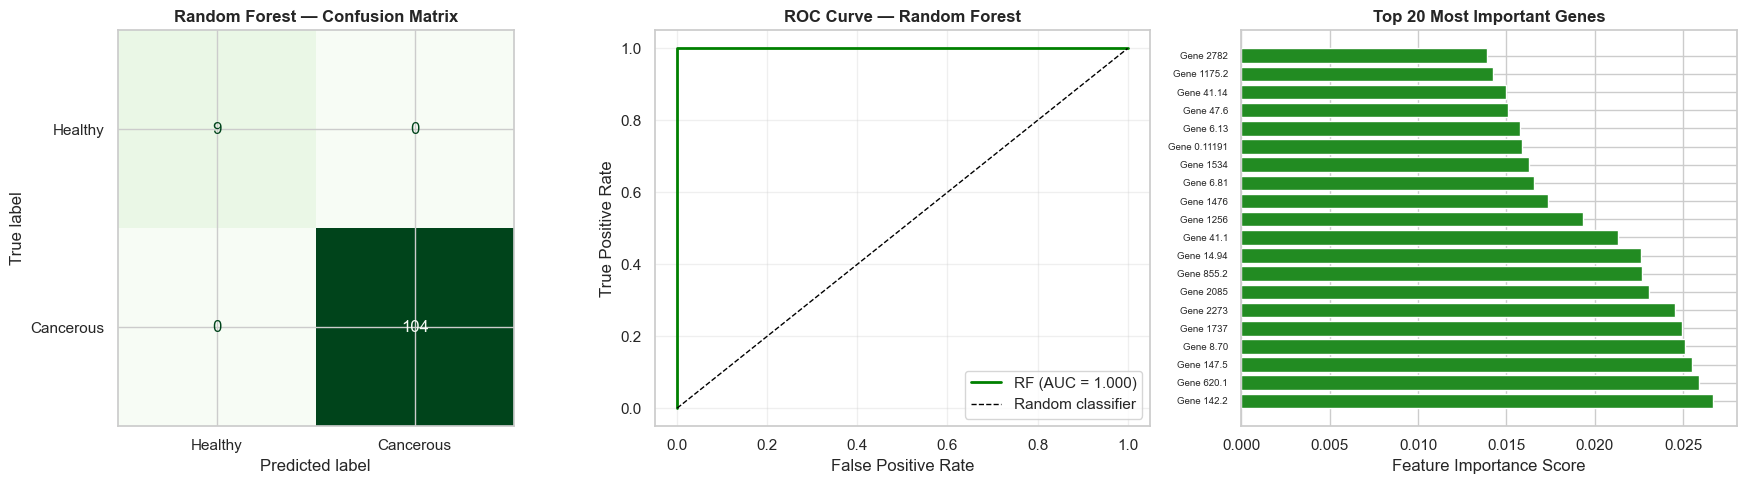


5-Fold CV F1-macro: 0.9154 +/- 0.1090


In [25]:
# ── Cell 18: Random Forest Evaluation ─────────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

print("=" * 55)
print("RANDOM FOREST — EVALUATION")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                            target_names=['Healthy (0)', 'Cancerous (1)']))

roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"ROC-AUC Score: {roc_auc_rf:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf,
                              display_labels=['Healthy', 'Cancerous'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Random Forest — Confusion Matrix', fontweight='bold')

# ROC curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[1].plot(fpr_rf, tpr_rf, color='green', lw=2,
             label=f'RF (AUC = {roc_auc_rf:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Random Forest', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Feature importance — top 20 genes
importances = pd.Series(rf_model.feature_importances_,
                        index=top500_genes)
top20 = importances.nlargest(20)
axes[2].barh(range(20), top20.values, color='forestgreen')
axes[2].set_yticks(range(20))
axes[2].set_yticklabels([f'Gene {g}' for g in top20.index], fontsize=7)
axes[2].set_title('Top 20 Most Important Genes', fontweight='bold')
axes[2].set_xlabel('Feature Importance Score')

plt.tight_layout()
plt.show()

# Cross validation
from sklearn.model_selection import cross_val_score
cv_scores_rf = cross_val_score(rf_model, X_train_scaled, y_train,
                               cv=5, scoring='f1_macro')
print(f"\n5-Fold CV F1-macro: {cv_scores_rf.mean():.4f} +/- {cv_scores_rf.std():.4f}")

## Neural Network

In [26]:
# ── Cell 19: Model 3 — Neural Network ─────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# For reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# ── Architecture ───────────────────────────────────────────────────
# Input: 500 genes
# Hidden layers: progressively smaller (500 → 256 → 128 → 64)
# Output: 1 neuron with sigmoid (binary classification)

model_nn = keras.Sequential([
    # Input layer
    layers.Input(shape=(X_train_scaled.shape[1],)),

    # Hidden layer 1
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),   # stabilizes training
    layers.Dropout(0.4),           # randomly drops 40% of neurons to prevent overfitting

    # Hidden layer 2
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    # Hidden layer 3
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),

    # Output layer — sigmoid for binary probability
    layers.Dense(1, activation='sigmoid')
])

# Compile
model_nn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_nn.summary()

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# ── Cell 20: Train Neural Network ─────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping

# Class weights to handle imbalance
class_counts = y_train.value_counts()
total = len(y_train)
class_weight_nn = {
    0: total / (2 * class_counts[0]),   # upweight healthy
    1: total / (2 * class_counts[1])    # downweight cancerous
}
print(f"Class weights: {class_weight_nn}")

# Early stopping — stops training if val_loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,           # wait 15 epochs before stopping
    restore_best_weights=True
)

# Train
history = model_nn.fit(
    X_train_scaled, y_train,
    epochs=150,
    batch_size=32,
    validation_split=0.15,    # 15% of training used for validation
    class_weight=class_weight_nn,
    callbacks=[early_stop],
    verbose=1
)

print("\nTraining complete ✓")

In [ ]:
# ── Cell 21: Training History ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history.history['val_loss'], label='Val Loss', color='orange')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy', color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network — Training History', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Cell 22: Neural Network Evaluation ────────────────────────────
# Predict
y_prob_nn = model_nn.predict(X_test_scaled).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print("=" * 55)
print("NEURAL NETWORK — EVALUATION")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nn,
                            target_names=['Healthy (0)', 'Cancerous (1)']))

roc_auc_nn = roc_auc_score(y_test, y_prob_nn)
print(f"ROC-AUC Score: {roc_auc_nn:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_nn)
disp = ConfusionMatrixDisplay(cm_nn,
                              display_labels=['Healthy', 'Cancerous'])
disp.plot(ax=axes[0], colorbar=False, cmap='Oranges')
axes[0].set_title('Neural Network — Confusion Matrix', fontweight='bold')

# ROC curve
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)
axes[1].plot(fpr_nn, tpr_nn, color='darkorange', lw=2,
             label=f'NN (AUC = {roc_auc_nn:.3f})')
axes[1].plot([0,1], [0,1], 'k--', lw=1, label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Neural Network', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()